# Notebook 2 — Health Insurance & Cancer SDOH Analysis

**TruBridge Externship | Iowa Colorectal Cancer (2016–2020)**

Analyzes health insurance coverage (ACS Table B27010) vs late-stage colorectal cancer. Age groups: 35–64 and 65+.

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd                          # choropleth maps
from scipy.stats import pearsonr, ttest_ind, mannwhitneyu, f_oneway
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


## 1. Load cancer registry data

> **Colab:** Upload all CSV files via the folder icon before running.

In [2]:
# ── Upload: county_colorectal_latestage_2016-2020.csv ────────────────────────
cancer_df = pd.read_csv('county_colorectal_latestage_2016-2020.csv')
cancer_df.rename(columns={'identifier':'County','AAR':'Number of New Cases per 100K',
                           'AARprob':'Cancer Risk Probability'}, inplace=True)
cancer_df.drop(columns='AARsd', inplace=True)
cancer_df.sort_values('County', inplace=True)
cancer_df.reset_index(drop=True, inplace=True)
cancer_df.columns = cancer_df.columns.str.strip()
assert len(cancer_df) == 99, f"Expected 99 counties, got {len(cancer_df)}"
print(f"Cancer data: {len(cancer_df)} counties | "
      f"Cancer Risk Probability range: {cancer_df['Cancer Risk Probability'].min():.4f}–{cancer_df['Cancer Risk Probability'].max():.4f}")
cancer_df.head()


Cancer data: 99 counties | Cancer Risk Probability range: 0.0100–0.5700


,County,Number of New Cases per 100K,Cancer Risk Probability,mapPop
0,Adair,18.99,0.25,5.2005
1,Adams,18.90,0.23,3.6579
2,Allamakee,18.15,0.11,8.3985
3,Appanoose,19.28,0.33,9.6327
4,Audubon,19.13,0.29,5.3292


## 2. Extract and prepare health insurance SDOH data

In [3]:
# ── Upload: ACS - B27010 - Health Insurance Types in IA - 2020 5 Yr Estimate (2016-20).csv
ins_raw = pd.read_csv('ACS - B27010 - Health Insurance Types in IA - 2020 5 Yr Estimate (2016-20).csv')

def clean_num(v):
    if pd.isna(v) or str(v).strip() in ('-','','N','X'): return np.nan
    try: return float(str(v).replace(',','').strip())
    except: return np.nan

age_35_64_rows = {
    'total_with_without_health_insurance':33,'total_with_one_health_insurance':34,
    'employer_only':35,'direct_purchase_only':36,'medicare_only':37,'medicaid_only':38,
    'tricare_only':39,'va_only':40,'total_with_two_or_more_health_insurance':41,
    'employer_direct':42,'employer_medicare':43,'direct_medicare':44,
    'medicare_medicaid':45,'other_private':46,'other_public':47,'other_combinations':48,'no_insurance':49}
age_65_plus_rows = {
    'total_with_without_health_insurance':50,'total_with_one_health_insurance':51,
    'employer_only':52,'direct_purchase_only':53,'medicare_only':54,'tricare_only':55,
    'va_only':56,'total_with_two_or_more_health_insurance':57,'employer_direct':58,
    'employer_medicare':59,'direct_medicare':60,'medicare_medicaid':61,'other_private':62,
    'other_public':63,'other_combinations':64,'no_insurance':65}

county_cols = [c for c in ins_raw.columns if 'County, Iowa!!Estimate' in c]
print(f"Found {len(county_cols)} counties in insurance dataset")

def extract_insurance(row_map, age_label):
    rows = []
    for col in county_cols:
        d = {'County':col.split('!!')[0].replace(' County, Iowa',''),'Age_Group':age_label}
        for k, idx in row_map.items(): d[k] = clean_num(ins_raw.iloc[idx][col])
        rows.append(d)
    return pd.DataFrame(rows)

def add_metrics(df):
    tot = df['total_with_without_health_insurance']
    df['pct_uninsured']         = (df['no_insurance'] / tot * 100).round(2)
    df['pct_private_insurance'] = ((df['employer_only']+df['direct_purchase_only']+df['employer_direct']) / tot * 100).round(2)
    medicaid = df['medicaid_only'] if 'medicaid_only' in df.columns else pd.Series(0, index=df.index)
    df['pct_government_insurance'] = ((medicaid+df['medicare_only']+df['tricare_only']+df['va_only']+
                                        df['employer_medicare']+df['direct_medicare']+df['medicare_medicaid']) / tot * 100).round(2)
    df['pct_employer_only']  = (df['employer_only']  / tot * 100).round(2)
    df['pct_medicare_only']  = (df['medicare_only']  / tot * 100).round(2)
    if 'medicaid_only' in df.columns:
        df['pct_medicaid_only'] = (df['medicaid_only'] / tot * 100).round(2)
    return df

ins_35_64  = add_metrics(extract_insurance(age_35_64_rows,  '35-64'))
ins_65plus = add_metrics(extract_insurance(age_65_plus_rows, '65+'))

health_df = (cancer_df
    .merge(ins_35_64,  on='County', how='inner')
    .merge(ins_65plus, on='County', how='inner', suffixes=('_35_64','_65_plus')))

# pct_medicaid_only has no name conflict so gets no auto-suffix — rename explicitly
health_df.rename(columns={'pct_medicaid_only':'pct_medicaid_only_35_64'}, inplace=True)
health_df.to_csv('iowa_colorectal_cancer_health_sdoh_2016-2020.csv', index=False)

# Risk tiers using actual min/max so no county falls outside bins
crp_min = health_df['Cancer Risk Probability'].min() - 0.001
crp_max = health_df['Cancer Risk Probability'].max() + 0.001
q = health_df['Cancer Risk Probability'].quantile([0.33,0.66]).values
health_df['risk_tier'] = pd.cut(health_df['Cancer Risk Probability'],
                                 bins=[crp_min,q[0],q[1],crp_max],
                                 labels=['Lower','Moderate','Higher'], include_lowest=True)
assert health_df['risk_tier'].isna().sum() == 0, "Counties with no risk tier — check bin boundaries"

print(f"Merged: {len(health_df)} counties | risk tiers: {health_df['risk_tier'].value_counts().to_dict()}")
health_df.head()


Found 99 counties in insurance dataset
Merged: 99 counties | risk tiers: {'Moderate': 36, 'Lower': 34, 'Higher': 29}


,County,Number of New Cases per 100K,Cancer Risk Probability,mapPop,Age_Group_35_64,total_with_without_health_insurance_35_64,total_with_one_health_insurance_35_64,employer_only_35_64,direct_purchase_only_35_64,medicare_only_35_64,...,other_private_65_plus,other_public_65_plus,other_combinations_65_plus,no_insurance_65_plus,pct_uninsured_65_plus,pct_private_insurance_65_plus,pct_government_insurance_65_plus,pct_employer_only_65_plus,pct_medicare_only_65_plus,risk_tier
0,Adair,18.99,0.25,5.2005,35-64,2691.0,2264.0,1582.0,332.0,33.0,...,0.0,45.0,333.0,0.0,0.00,1.10,72.85,0.83,24.95,Moderate
1,Adams,18.90,0.23,3.6579,35-64,1389.0,1135.0,738.0,216.0,15.0,...,0.0,17.0,184.0,0.0,0.00,1.75,73.09,0.50,23.15,Moderate
2,Allamakee,18.15,0.11,8.3985,35-64,5051.0,4187.0,2982.0,644.0,33.0,...,0.0,48.0,506.0,19.0,0.65,3.11,77.33,2.49,23.66,Lower
3,Appanoose,19.28,0.33,9.6327,35-64,4697.0,3872.0,2230.0,533.0,97.0,...,0.0,120.0,560.0,0.0,0.00,0.43,75.44,0.07,23.42,Higher
4,Audubon,19.13,0.29,5.3292,35-64,2140.0,1754.0,1066.0,376.0,38.0,...,0.0,30.0,155.0,0.0,0.00,1.51,83.78,1.51,27.03,Higher


## 3. Geographic overview and top-10 county charts

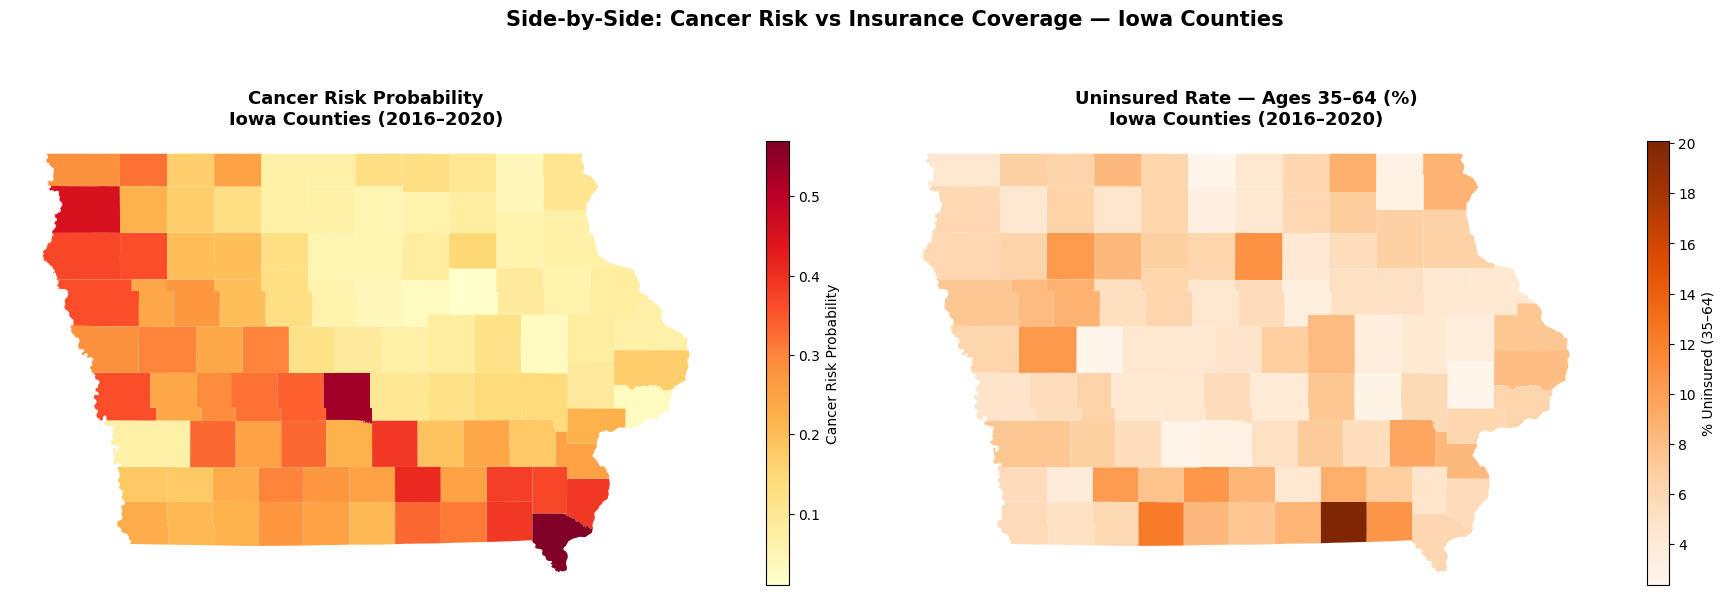

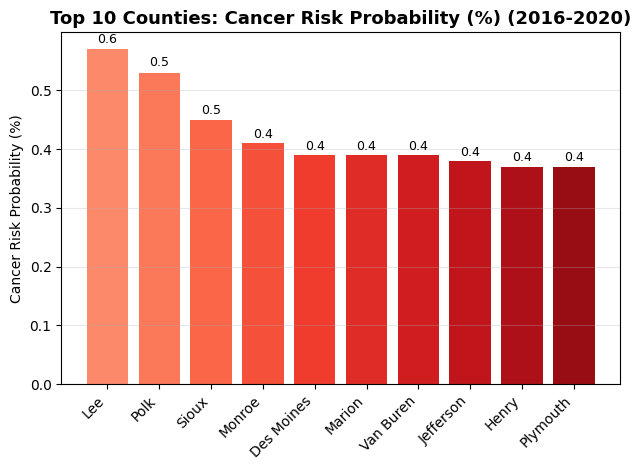

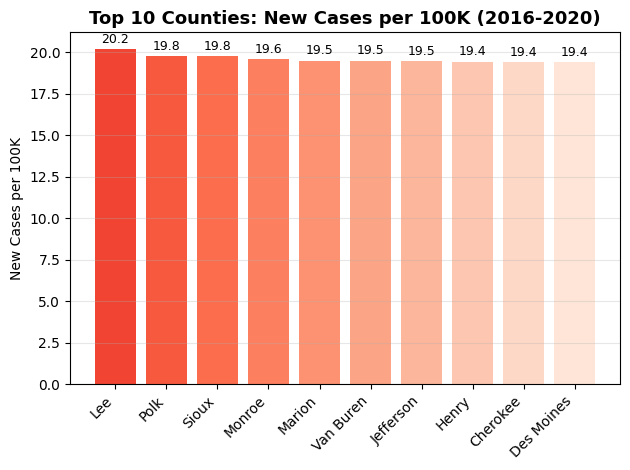

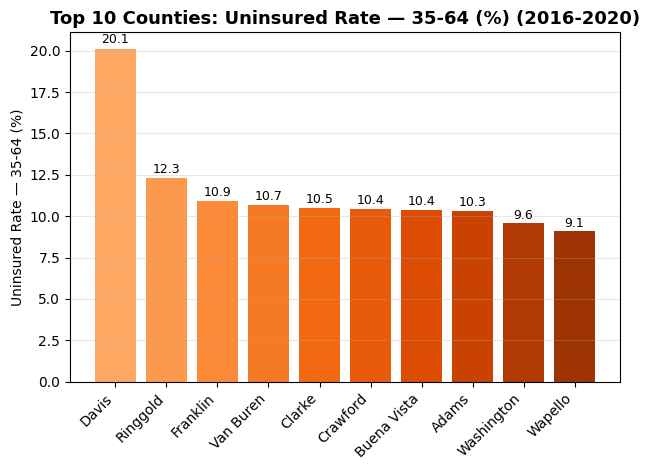

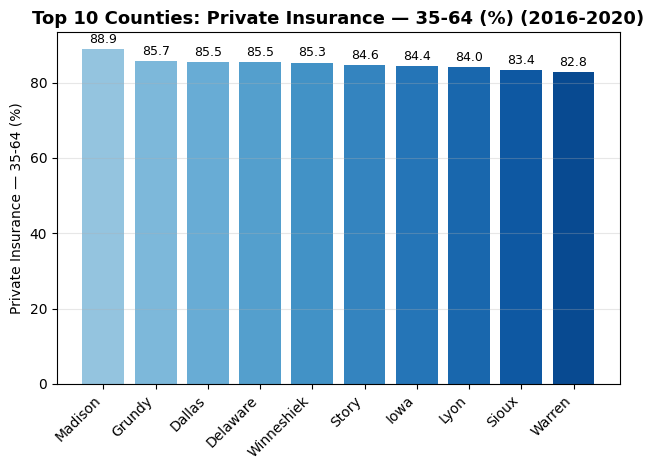

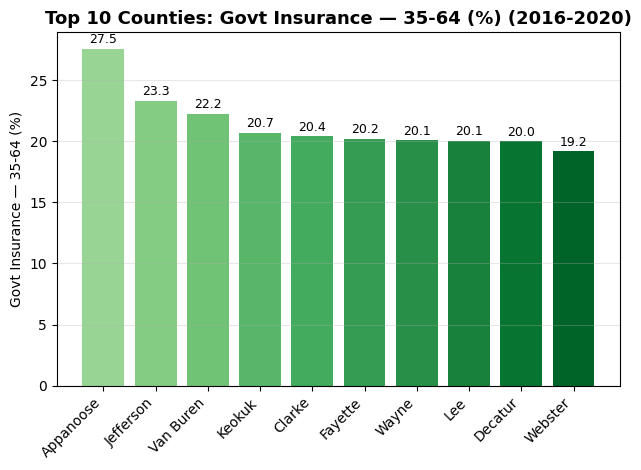

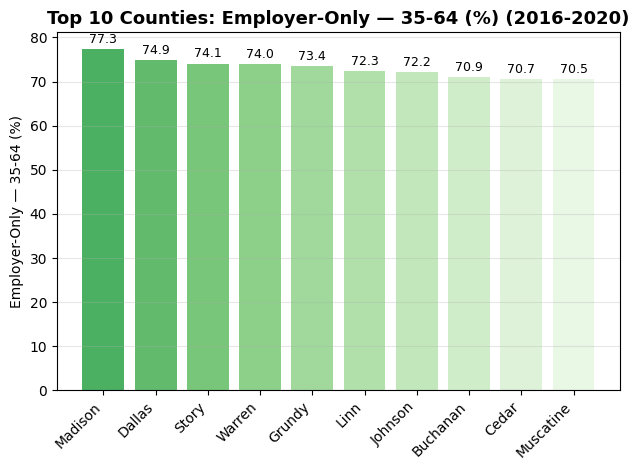

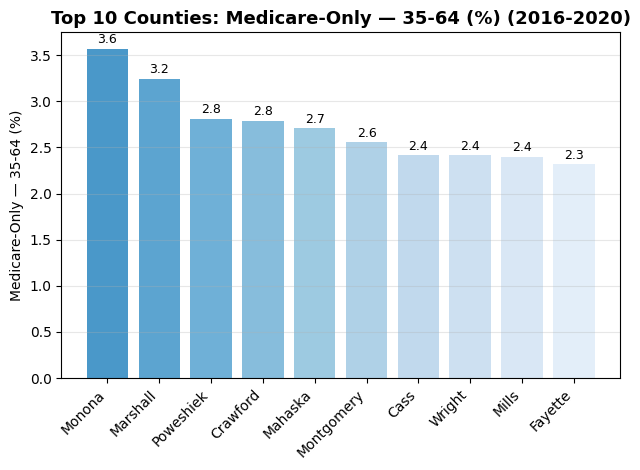

In [4]:
# ── Choropleth: Cancer Risk vs Uninsured Rate (35-64) ────────────────────────
gdf      = gpd.read_file("https://www2.census.gov/geo/tiger/TIGER2022/COUNTY/tl_2022_us_county.zip")
iowa_gdf = gdf[gdf['STATEFP']=='19'].copy()
iowa_gdf['NAME'] = iowa_gdf['NAME'].str.strip()
map_df   = iowa_gdf.merge(health_df, left_on='NAME', right_on='County', how='left')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
map_df.plot(column='Cancer Risk Probability', ax=axes[0], legend=True, cmap='YlOrRd',
            missing_kwds={'color':'lightgrey'}, legend_kwds={'label':'Cancer Risk Probability','shrink':0.7})
axes[0].set_title('Cancer Risk Probability\nIowa Counties (2016–2020)', fontsize=13, fontweight='bold')
axes[0].axis('off')
map_df.plot(column='pct_uninsured_35_64', ax=axes[1], legend=True, cmap='Oranges',
            missing_kwds={'color':'lightgrey'}, legend_kwds={'label':'% Uninsured (35–64)','shrink':0.7})
axes[1].set_title('Uninsured Rate — Ages 35–64 (%)\nIowa Counties (2016–2020)', fontsize=13, fontweight='bold')
axes[1].axis('off')
plt.suptitle('Side-by-Side: Cancer Risk vs Insurance Coverage — Iowa Counties', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Top-10 county bar charts ──────────────────────────────────────────────────
bar_configs = [
    ('Cancer Risk Probability',        'Cancer Risk Probability (%)',     plt.cm.Reds),
    ('Number of New Cases per 100K',   'New Cases per 100K',              plt.cm.Reds_r),
    ('pct_uninsured_35_64',           'Uninsured Rate — 35-64 (%)',      plt.cm.Oranges),
    ('pct_private_insurance_35_64',   'Private Insurance — 35-64 (%)',   plt.cm.Blues),
    ('pct_government_insurance_35_64','Govt Insurance — 35-64 (%)',      plt.cm.Greens),
    ('pct_employer_only_35_64',       'Employer-Only — 35-64 (%)',       plt.cm.Greens_r),
    ('pct_medicare_only_35_64',       'Medicare-Only — 35-64 (%)',       plt.cm.Blues_r),
]
for col, ylabel, cmap in bar_configs:
    top10 = health_df.nlargest(10, col)
    bars  = plt.bar(range(10), top10[col], color=cmap(np.linspace(0.4,0.9,10)))
    plt.title(f'Top 10 Counties: {ylabel} (2016-2020)', fontsize=13, fontweight='bold')
    plt.xticks(range(10), top10['County'], rotation=45, ha='right')
    plt.ylabel(ylabel); plt.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, top10[col]):
        plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                 f'{val:.1f}', ha='center', va='bottom', fontsize=9)
    plt.tight_layout(); plt.show()


## 4. Ages 35–64 analysis

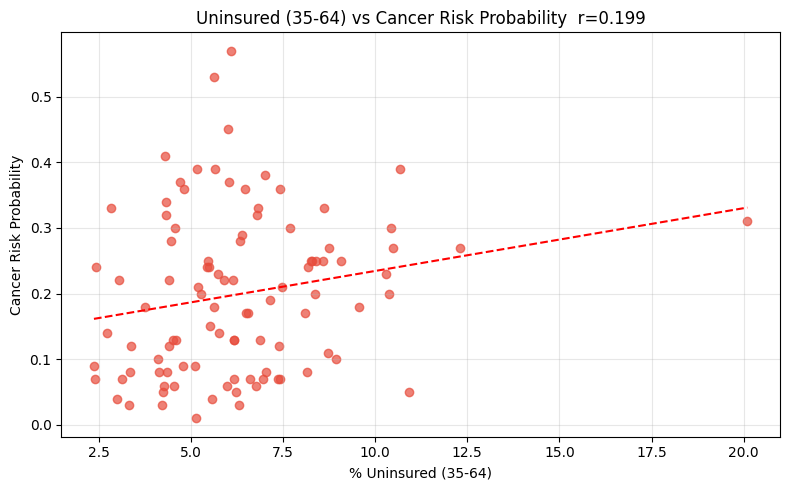

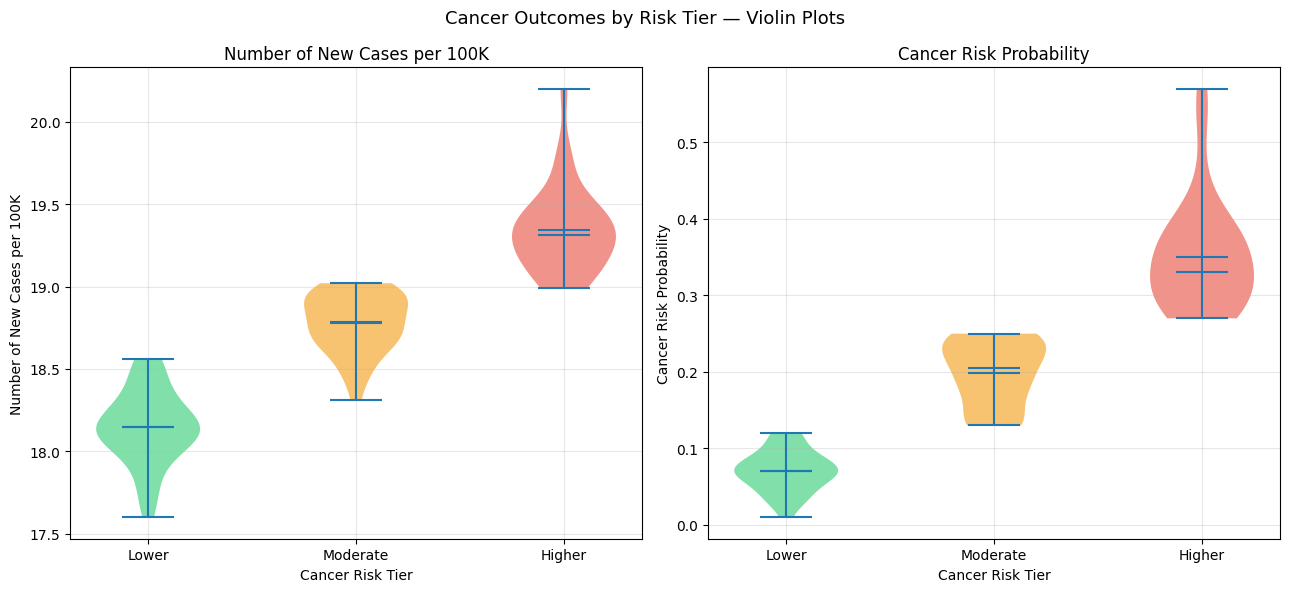

/tmp/ipykernel_6501/2814856450.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(box_data, labels=tiers, patch_artist=True)


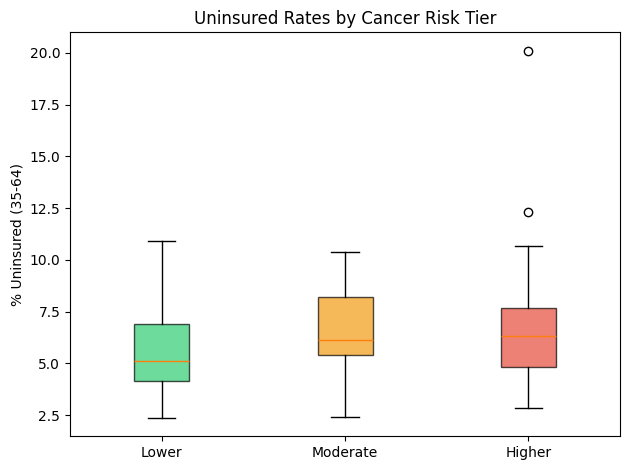

ANOVA — F=3.235, p=0.0437 (significant)


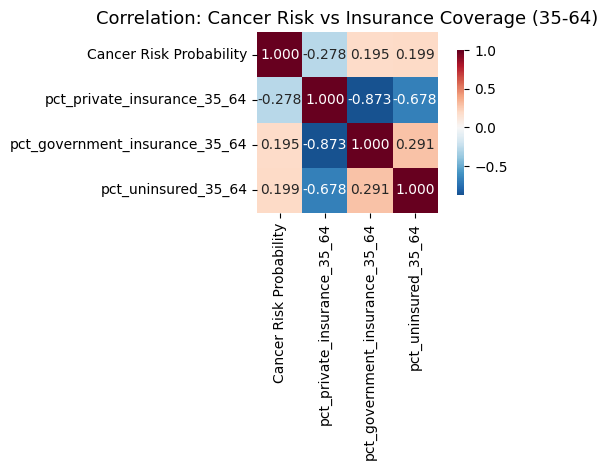

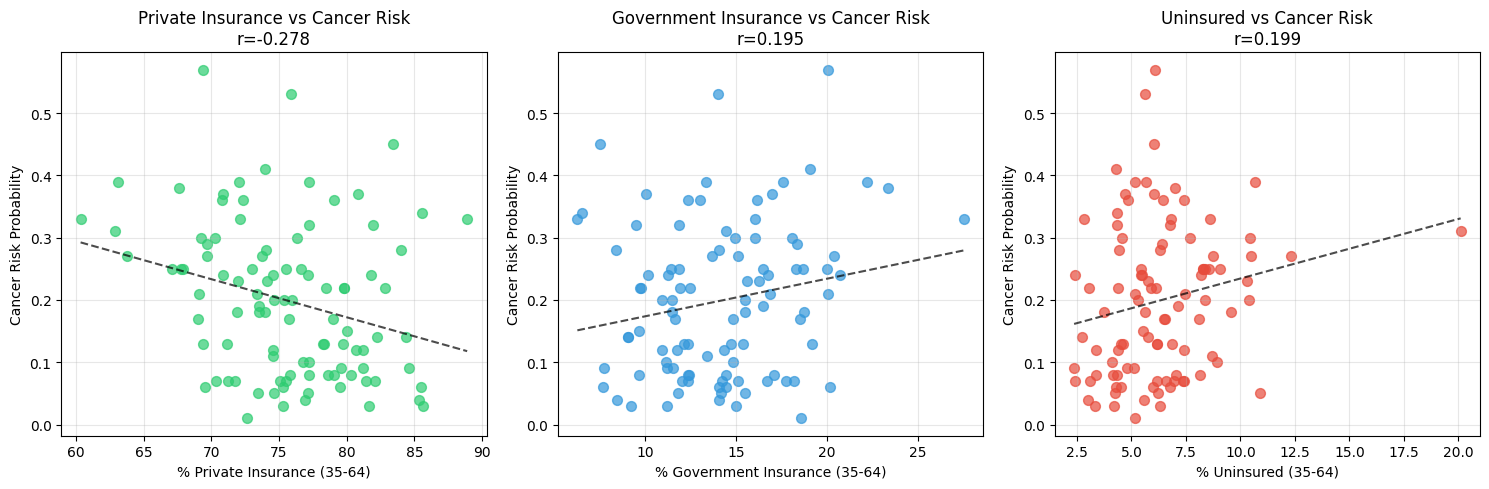

In [5]:
# ── Scatter: uninsured (35-64) vs Cancer Risk ─────────────────────────────────
plt.figure(figsize=(8,5))
x = health_df['pct_uninsured_35_64'].values
y = health_df['Cancer Risk Probability'].values
plt.scatter(x, y, alpha=0.7, color='#e74c3c')
plt.plot(np.sort(x), np.poly1d(np.polyfit(x,y,1))(np.sort(x)), 'r--')
r = np.corrcoef(x,y)[0,1]
plt.title(f'Uninsured (35-64) vs Cancer Risk Probability  r={r:.3f}')
plt.xlabel('% Uninsured (35-64)'); plt.ylabel('Cancer Risk Probability')
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# ── Violin plots by risk tier ─────────────────────────────────────────────────
tiers  = ['Lower','Moderate','Higher']
colors = ['#2ecc71','#f39c12','#e74c3c']
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, col in zip(axes, ['Number of New Cases per 100K','Cancer Risk Probability']):
    groups = [health_df[health_df['risk_tier']==t][col].dropna() for t in tiers]
    parts  = ax.violinplot(groups, positions=[1,2,3], showmedians=True, showmeans=True)
    for pc, c in zip(parts['bodies'], colors): pc.set_facecolor(c); pc.set_alpha(0.6)
    ax.set_xticks([1,2,3]); ax.set_xticklabels(tiers)
    ax.set_ylabel(col); ax.set_xlabel('Cancer Risk Tier'); ax.grid(True, alpha=0.3); ax.set_title(col)
plt.suptitle('Cancer Outcomes by Risk Tier — Violin Plots', fontsize=13)
plt.tight_layout(); plt.show()

# ── Box plot + ANOVA ──────────────────────────────────────────────────────────
box_data = [health_df[health_df['risk_tier']==t]['pct_uninsured_35_64'].dropna() for t in tiers]
bp = plt.boxplot(box_data, labels=tiers, patch_artist=True)
for patch, c in zip(bp['boxes'], colors): patch.set_facecolor(c); patch.set_alpha(0.7)
plt.ylabel('% Uninsured (35-64)'); plt.title('Uninsured Rates by Cancer Risk Tier')
plt.tight_layout(); plt.show()
F, p = f_oneway(*box_data)
print(f"ANOVA — F={F:.3f}, p={p:.4f} ({'significant' if p<0.05 else 'not significant'})")

# ── Correlation heatmap (35-64) ───────────────────────────────────────────────
corr_vars = ['Cancer Risk Probability','pct_private_insurance_35_64',
             'pct_government_insurance_35_64','pct_uninsured_35_64']
sns.heatmap(health_df[corr_vars].corr(), annot=True, cmap='RdBu_r', center=0,
            square=True, fmt='.3f', cbar_kws={'shrink':.8})
plt.title('Correlation: Cancer Risk vs Insurance Coverage (35-64)', fontsize=13)
plt.tight_layout(); plt.show()

# ── Scatter matrix (35-64) ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax,(var,color,title) in zip(axes,[
    ('pct_private_insurance_35_64',   '#2ecc71','Private Insurance'),
    ('pct_government_insurance_35_64','#3498db','Government Insurance'),
    ('pct_uninsured_35_64',           '#e74c3c','Uninsured')]):
    xv = health_df[var].values; yv = health_df['Cancer Risk Probability'].values
    ax.scatter(xv, yv, alpha=0.7, s=50, color=color)
    ax.plot(np.sort(xv), np.poly1d(np.polyfit(xv,yv,1))(np.sort(xv)), 'k--', alpha=0.7)
    ax.set_title(f'{title} vs Cancer Risk\nr={np.corrcoef(xv,yv)[0,1]:.3f}')
    ax.set_xlabel(f'% {title} (35-64)'); ax.set_ylabel('Cancer Risk Probability')
    ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 5. Age group comparison and interaction analysis

⚠️  iowa_colorectal_cancer_poverty_sdoh_2016-2020.csv not found.
    Upload it to Colab (it was exported by Notebook 1) and re-run this cell.


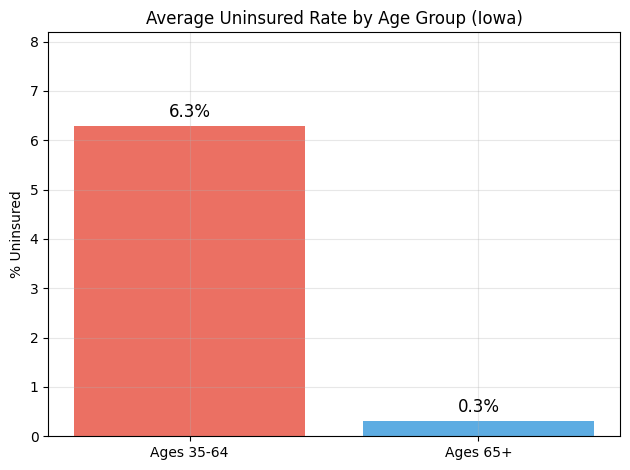

Correlation uninsured (65+) vs Cancer Risk: r=0.082
Correlation uninsured (35-64) vs Cancer Risk: r=0.199


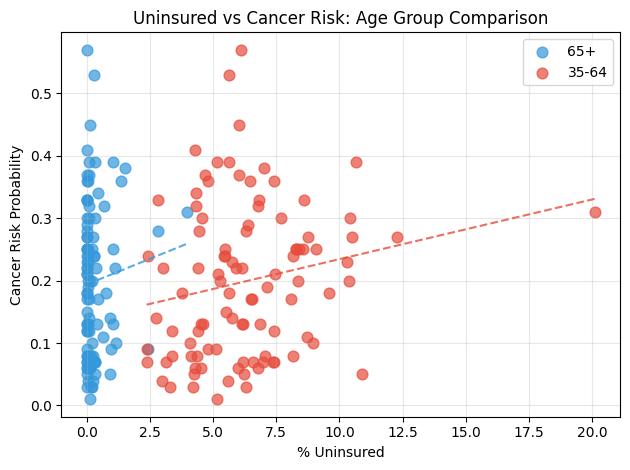

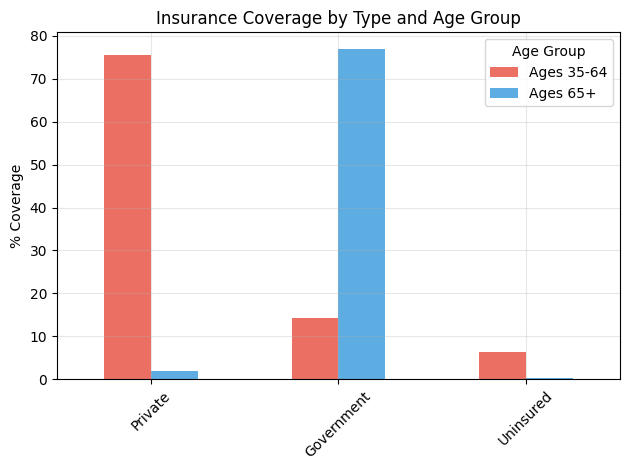

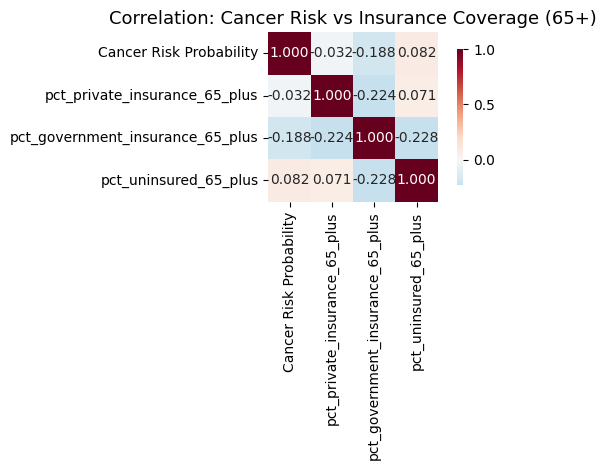

Uninsured: t=22.757, p=0.0000 — significant
Private ins.: t=129.617, p=0.0000 — significant
Govt ins.: t=-119.651, p=0.0000 — significant


In [6]:
# ── Interaction plot: does poverty moderate the insurance–cancer link? ─────────
# Requires iowa_colorectal_cancer_poverty_sdoh_2016-2020.csv (produced by NB1)
# FIX: load poverty CSV from the uploaded file path directly so this cell works
# even if NB1 was not run in this same Colab session.
try:
    pov_tmp     = pd.read_csv('iowa_colorectal_cancer_poverty_sdoh_2016-2020.csv')[['County','Overall_Poverty']]
    interact_df = health_df.merge(pov_tmp, on='County', how='left')
    pov_median  = interact_df['Overall_Poverty'].median()
    high_pov    = interact_df[interact_df['Overall_Poverty'] >  pov_median]
    low_pov     = interact_df[interact_df['Overall_Poverty'] <= pov_median]
    print(f"Poverty data loaded: median = {pov_median:.1f}%, "
          f"{len(low_pov)} low-poverty counties, {len(high_pov)} high-poverty counties")

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for ax, (ins_var, title) in zip(axes, [
        ('pct_uninsured_35_64',         '% Uninsured (35-64)'),
        ('pct_private_insurance_35_64', '% Private Insurance (35-64)')]):
        for grp, color, label in [
            (low_pov,  '#2ecc71', f'Low Poverty (≤{pov_median:.1f}%)'),
            (high_pov, '#e74c3c', f'High Poverty (>{pov_median:.1f}%)')]:
            clean = grp[[ins_var, 'Cancer Risk Probability']].dropna()
            xv, yv = clean[ins_var].values, clean['Cancer Risk Probability'].values
            ax.scatter(xv, yv, color=color, alpha=0.6, s=50, label=label)
            if len(xv) > 1:
                xs = np.sort(xv)
                ax.plot(xs, np.poly1d(np.polyfit(xv, yv, 1))(xs), color=color, linewidth=2)
                r = np.corrcoef(xv, yv)[0, 1]
                ax.annotate(f'r={r:.3f}',
                            xy=(xs[-1], np.poly1d(np.polyfit(xv, yv, 1))(xs[-1])),
                            color=color, fontsize=9, fontweight='bold',
                            xytext=(-40, 6), textcoords='offset points')
        ax.set_xlabel(title); ax.set_ylabel('Cancer Risk Probability')
        ax.set_title(f'Interaction: {title}\n× Poverty Level → Cancer Risk')
        ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    plt.suptitle('Does Poverty Moderate the Insurance–Cancer Relationship?',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

except FileNotFoundError:
    print("⚠️  iowa_colorectal_cancer_poverty_sdoh_2016-2020.csv not found.")
    print("    Upload it to Colab (it was exported by Notebook 1) and re-run this cell.")

# ── Age group comparison ──────────────────────────────────────────────────────
age_means = health_df[['pct_uninsured_35_64', 'pct_uninsured_65_plus']].mean()
bars = plt.bar(['Ages 35-64', 'Ages 65+'], age_means, color=['#e74c3c', '#3498db'], alpha=0.8)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=12)
plt.ylabel('% Uninsured'); plt.title('Average Uninsured Rate by Age Group (Iowa)')
plt.ylim(0, age_means.max() * 1.3); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# ── Overlay scatter: both age groups ─────────────────────────────────────────
for col, color, label in [('pct_uninsured_65_plus', '#3498db', '65+'),
                           ('pct_uninsured_35_64',  '#e74c3c', '35-64')]:
    xv = health_df[col].values; yv = health_df['Cancer Risk Probability'].values
    plt.scatter(xv, yv, alpha=0.7, s=60, color=color, label=label)
    plt.plot(np.sort(xv), np.poly1d(np.polyfit(xv, yv, 1))(np.sort(xv)),
             color=color, linestyle='--', alpha=0.8)
    print(f"Correlation uninsured ({label}) vs Cancer Risk: r={np.corrcoef(xv,yv)[0,1]:.3f}")
plt.xlabel('% Uninsured'); plt.ylabel('Cancer Risk Probability')
plt.title('Uninsured vs Cancer Risk: Age Group Comparison')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# ── Insurance type comparison by age + 65+ heatmap + t-tests ─────────────────
comp = pd.DataFrame({
    'Ages 35-64': [health_df[f'pct_{t}_insurance_35_64'].mean() for t in ['private', 'government']]
                  + [health_df['pct_uninsured_35_64'].mean()],
    'Ages 65+':   [health_df[f'pct_{t}_insurance_65_plus'].mean() for t in ['private', 'government']]
                  + [health_df['pct_uninsured_65_plus'].mean()],
}, index=['Private', 'Government', 'Uninsured'])
comp.plot(kind='bar', color=['#e74c3c', '#3498db'], alpha=0.8)
plt.ylabel('% Coverage'); plt.title('Insurance Coverage by Type and Age Group')
plt.xticks(rotation=45); plt.legend(title='Age Group'); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

vars_65 = ['Cancer Risk Probability', 'pct_private_insurance_65_plus',
           'pct_government_insurance_65_plus', 'pct_uninsured_65_plus']
sns.heatmap(health_df[vars_65].corr(), annot=True, cmap='RdBu_r', center=0,
            square=True, fmt='.3f', cbar_kws={'shrink': .8})
plt.title('Correlation: Cancer Risk vs Insurance Coverage (65+)', fontsize=13)
plt.tight_layout(); plt.show()

for t_type, col1, col2 in [
    ('Uninsured',   'pct_uninsured_35_64',           'pct_uninsured_65_plus'),
    ('Private ins.','pct_private_insurance_35_64',    'pct_private_insurance_65_plus'),
    ('Govt ins.',   'pct_government_insurance_35_64', 'pct_government_insurance_65_plus')]:
    t, p = ttest_ind(health_df[col1].dropna(), health_df[col2].dropna())
    print(f"{t_type}: t={t:.3f}, p={p:.4f} — {'significant' if p<0.05 else 'not significant'}")


## Health Insurance vs Cancer — Key Findings

**Insurance coverage type is the strongest single SDOH predictor found in this study.** The key results:

- Uninsured rate (35–64) vs Cancer Risk Probability: r = +0.199, p = 0.048 — significant
- ANOVA across risk tiers: F = 3.235, p = 0.044 — uninsured rates differ significantly between lower, moderate, and higher cancer risk counties

The scatter plots and heatmap both show a consistent pattern: counties with higher private insurance coverage tend toward lower cancer risk, while higher uninsured rates track toward higher risk — though the effect is modest (r ≈ 0.2).

**The Medicare effect is the clearest finding in this notebook.** The age group comparison shows an average uninsured rate of ~5.6% for ages 35–64 dropping to near-zero for ages 65+, and the correlation between uninsured rate and cancer risk falls from r = +0.199 for the younger group to r = +0.082 for the older group. This is consistent with near-universal Medicare coverage effectively removing insurance as a risk differentiator for seniors.